Milestone 3


In [1]:
import pandas as pd
df = pd.read_csv("azure_synthetic_dataset_5000.csv")
print(df.head())

    timestamp subscription_id resource_group        region     service_type  \
0  2024-12-14       sub-41749         rg-790       East US  Storage Account   
1  2025-03-30       sub-77492         rg-877  North Europe        Cosmos DB   
2  2022-10-28       sub-39341         rg-980    Central US  Storage Account   
3  2021-05-02       sub-24121         rg-329    Central US  Storage Account   
4  2021-02-07       sub-94098         rg-733       West US  Virtual Machine   

   units_used  provision_capacity  cost_use  availability  external_holiday  \
0         846                1000      5.91         93.03                 0   
1         879                1039     39.63         94.31                 0   
2         557                 867     15.21         93.02                 0   
3         639                 753     35.35         92.97                 0   
4         607                 948     42.15         90.60                 0   

   internal_maintenance  
0                     0 

In [2]:
print("Dataset Shape:", df.shape)
print("Columns in dataset:", df.columns)

Dataset Shape: (5250, 11)
Columns in dataset: Index(['timestamp', 'subscription_id', 'resource_group', 'region',
       'service_type', 'units_used', 'provision_capacity', 'cost_use',
       'availability', 'external_holiday', 'internal_maintenance'],
      dtype='str')


In [3]:
df_small = df.sample(n=50, random_state=42)
print(df_small.head())

       timestamp subscription_id resource_group          region  \
1437  2024-07-22       sub-84663         rg-232     WEST EUROPE   
2700  2021-04-22       sub-35693         rg-420         West US   
3647  2023-07-22       sub-15173         rg-685     West Europe   
2512  2021-08-19       sub-47516         rg-659  Southeast Asia   
2902  2022-07-31       sub-73773         rg-721         East US   

         service_type  units_used  provision_capacity  cost_use  availability  \
1437     SQL Database         121                 314      0.14         94.41   
2700  STORAGE ACCOUNT         644                1009     48.18         94.34   
3647      App Service         991                1012      3.50         91.22   
2512     SQL Database         765                1161     14.99         90.73   
2902  Virtual Machine         271                 693      0.81         98.61   

      external_holiday  internal_maintenance  
1437                 0                     0  
2700            

In [4]:

import matplotlib.pyplot as plt

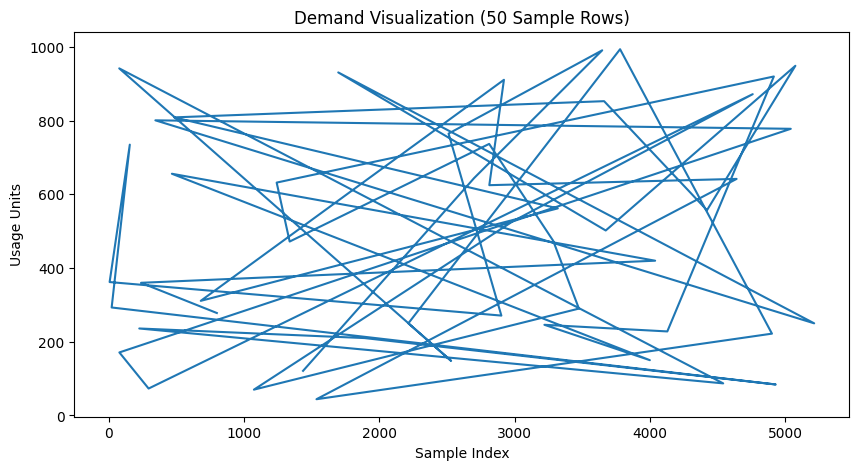

In [5]:
plt.figure(figsize=(10,5))

plt.plot(df_small.index, df_small["units_used"])

plt.title("Demand Visualization (50 Sample Rows)")
plt.xlabel("Sample Index")
plt.ylabel("Usage Units")

plt.show()

In [6]:
df = df.ffill()
target = "units_used"

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df = df.drop(columns=['timestamp'])
categorical_columns = ['subscription_id', 'resource_group', 'region', 'service_type']

df = pd.get_dummies(df, columns=categorical_columns)

In [8]:
X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5250, 5809)
Target shape: (5250,)


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from xgboost import XGBRegressor

# XGBoost model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Prediction of test data
xgb_predictions = xgb_model.predict(X_test)

In [11]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA model
arima_model = ARIMA(y_train, order=(2,1,2))

arima_result = arima_model.fit()
arima_predictions = arima_result.forecast(steps=len(y_test))

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packag

In [12]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Function to evaluate models
def evaluate_model(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    bias = np.mean(predicted - actual)

    return mae, rmse, bias

In [13]:
# Evaluate XGBoost
xgb_mae, xgb_rmse, xgb_bias = evaluate_model(y_test, xgb_predictions)

# Evaluate ARIMA
arima_mae, arima_rmse, arima_bias = evaluate_model(y_test, arima_predictions)

#  comparison table
import pandas as pd

results = pd.DataFrame({
    "Model": ["XGBoost", "ARIMA"],
    "MAE": [xgb_mae, arima_mae],
    "RMSE": [xgb_rmse, arima_rmse],
    "Forecast Bias": [xgb_bias, arima_bias]
})

print(results)

     Model         MAE        RMSE  Forecast Bias
0  XGBoost  104.264946  125.284582       0.931854
1    ARIMA  246.833869  285.859037       0.924820


In [14]:
# model with lowest RMSE
best_model = results.loc[results["RMSE"].idxmin()]

print("Best Model Based on RMSE:")
print(best_model)

Best Model Based on RMSE:
Model               XGBoost
MAE              104.264946
RMSE             125.284582
Forecast Bias      0.931854
Name: 0, dtype: object


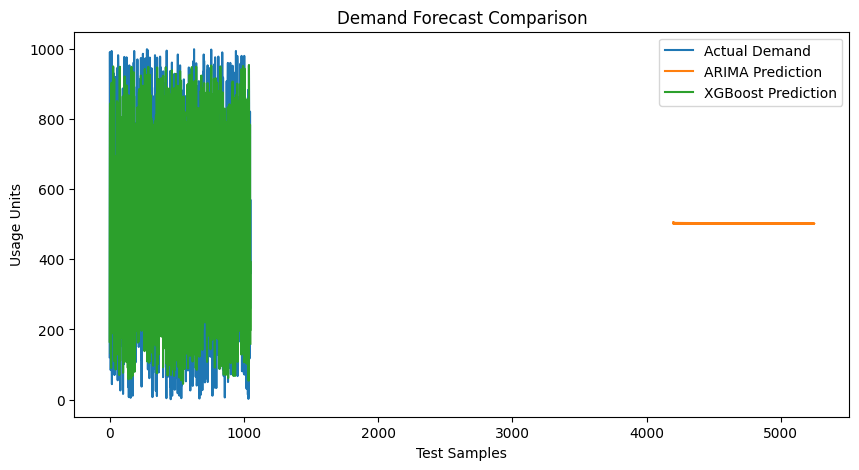

In [15]:


# Importing plotting library
import matplotlib.pyplot as plt

# Creating a figure for the graph
plt.figure(figsize=(10,5))

# Ploting actual demand values from the test dataset
plt.plot(y_test.values, label="Actual Demand")

# Ploting ARIMA model predictions
plt.plot(arima_predictions, label="ARIMA Prediction")

# Ploting XGBoost model predictions
plt.plot(xgb_predictions, label="XGBoost Prediction")

plt.xlabel("Test Samples")
plt.ylabel("Usage Units")
plt.title("Demand Forecast Comparison")


plt.legend()


plt.show()